#  3. EDA: Описательная статистика

## Описание проекта

**Датасет:** Brazilian E-Commerce Public Dataset by Olist (2016–2018).

**Предыдущий этап:** в ноутбуке [01_Data_Analyst_Cleaning_and_Vitrina](../notebooks/01_Data_Analyst_Cleaning_and_Vitrina.ipynb)
проведён первичный анализ данных, анализ пропусков и построение витрины. 
Готовая витрина загружается с Google Drive.

**Задачи ноутбука:**
*   Загрузить витрину и провести разведочный анализ (EDA): ключевые метрики, 
    распределения, сезонность, категории, география.
*   Проверить гипотезы о факторах, влияющих на время доставки и удовлетворённость клиентов.
*   Корреляционный анализ: Пирсон, point-biserial correlation, Cramér's V.
*   Сформулировать ключевые инсайты и рекомендации для бизнеса.

**Источник данных:** [Kaggle — Olist](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce)

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# Палитра
selected_palette = sns.color_palette("RdYlGn", n_colors=20)

# Загрузка витрины с Google Drive
file_id = "1OOmYSXfpSI9jX_b6WAQkBg7JVVqxZGbl"
url = f"https://drive.google.com/uc?id={file_id}"
df = pd.read_csv(url)
print(f"Витрина загружена: {df.shape}")

Витрина загружена: (115712, 28)


#### Ключевые метрики

Смотрим на основные показатели: выручка, средний чек, количество заказов и клиентов.

In [30]:
# Общая выручка
total_revenue = df['payment_value'].sum()
print(f"Общая выручка: {total_revenue:,.0f} BRL")

# Средний чек на заказ
order_revenue = df.groupby('order_id')['payment_value'].sum()
avg_check = order_revenue.mean()
print(f"Средний чек: {avg_check:,.0f} BRL")

# Медианный чек
median_check = order_revenue.median()
print(f"Медианный чек: {median_check:,.0f} BRL")

# Количество уникальных заказов
total_orders = df['order_id'].nunique()
print(f"Заказов: {total_orders}")

# Количество уникальных клиентов
total_customers = df['customer_id'].nunique()
print(f"Клиентов: {total_customers}")

# Среднее количество заказов на клиента
orders_per_customer = total_orders / total_customers
print(f"Среднее заказов на клиента: {orders_per_customer:.2f}")

Общая выручка: 19,880,566 BRL
Средний чек: 206 BRL
Медианный чек: 110 BRL
Заказов: 96469
Клиентов: 96469
Среднее заказов на клиента: 1.00


In [31]:
# Распределение суммы платежа
df['payment_value'].describe()

count    115712.000000
mean        171.810756
std         265.650941
min           0.000000
25%          60.850000
50%         108.110000
75%         188.940000
max       13664.080000
Name: payment_value, dtype: float64

**Базовые метрики:**
*   Общая выручка за период — 19.88M BRL.
*   Средний чек — 206 BRL, медианный — 110 BRL. Разница между средним и медианой указывает на выбросы (крупные заказы).
*   Среднее заказов на клиента — 1.0: большинство покупателей совершают только одну покупку.
*   Максимальный платёж — 13 664 BRL.
*   50% заказов — в диапазоне 61–189 BRL.

### Выручка по месяцам

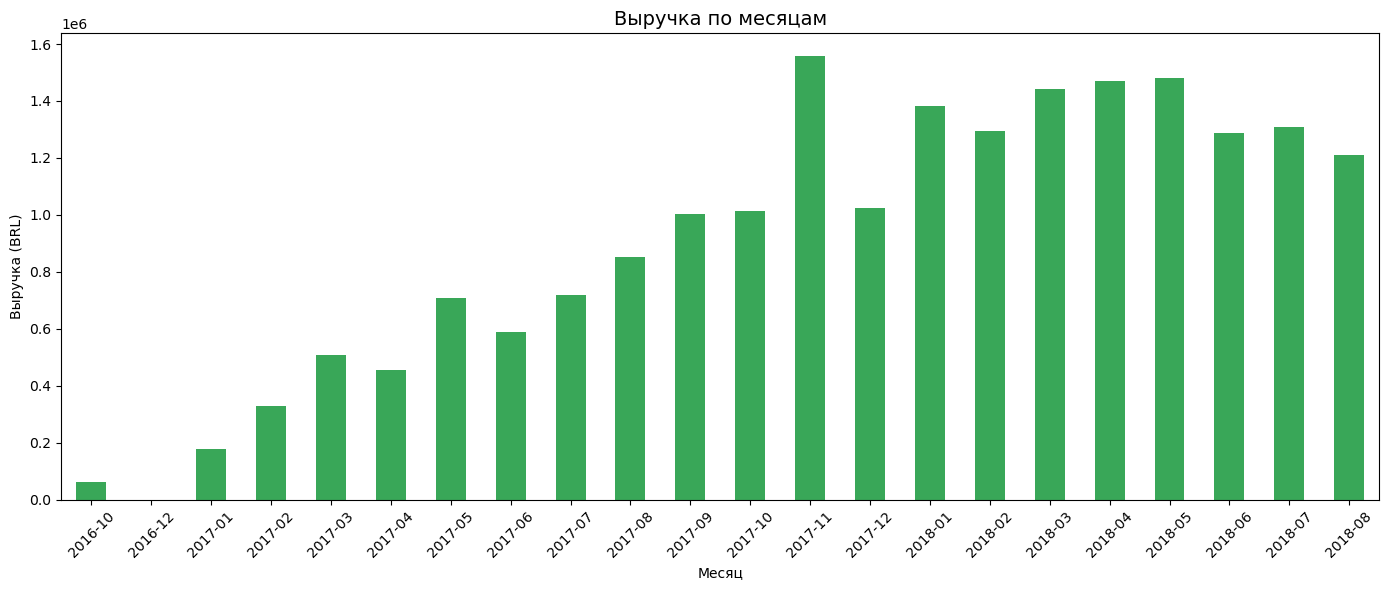

In [32]:
# Преобразуем дату
df['order_month'] = pd.to_datetime(df['order_purchase_timestamp']).dt.to_period('M')
monthly_revenue = df.groupby('order_month')['payment_value'].sum()

plt.figure(figsize=(14, 6))
monthly_revenue.plot(kind='bar', color=selected_palette[17])
plt.title('Выручка по месяцам', fontsize=14)
plt.xlabel('Месяц')
plt.ylabel('Выручка (BRL)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [33]:
# Выручка по месяцам — таблица
monthly_revenue_df = monthly_revenue.reset_index()
monthly_revenue_df.columns = ['Месяц', 'Выручка']
monthly_revenue_df['Выручка'] = monthly_revenue_df['Выручка'].round(0).astype(int)

# Добавляем изменение к предыдущему месяцу
monthly_revenue_df['Изменение, %'] = monthly_revenue_df['Выручка'].pct_change().mul(100).round(1)

print(f"Период: {monthly_revenue_df['Месяц'].iloc[0]} — {monthly_revenue_df['Месяц'].iloc[-1]}")
print(f"Среднемесячная выручка: {monthly_revenue_df['Выручка'].mean():,.0f} BRL")
print(f"Максимум: {monthly_revenue_df['Месяц'].iloc[monthly_revenue_df['Выручка'].argmax()]} — {monthly_revenue_df['Выручка'].max():,} BRL")
print(f"Минимум: {monthly_revenue_df['Месяц'].iloc[monthly_revenue_df['Выручка'].argmin()]} — {monthly_revenue_df['Выручка'].min():,} BRL")
print()

monthly_revenue_df

Период: 2016-10 — 2018-08
Среднемесячная выручка: 903,662 BRL
Максимум: 2017-11 — 1,559,605 BRL
Минимум: 2016-12 — 20 BRL



,Месяц,Выручка,"Изменение, %"
0,2016-10,62186,NaN
1,2016-12,20,-100.0
2,2017-01,178282,891310.0
3,2017-02,327929,83.9
4,2017-03,508767,55.1
5,2017-04,457050,-10.2
6,2017-05,706849,54.7
7,2017-06,590224,-16.5
8,2017-07,720447,22.1
9,2017-08,850611,18.1


**Выручка по месяцам:**
*   Период: октябрь 2016 — август 2018.
*   Среднемесячная выручка: 904 тыс BRL.
*   Выручка растёт с октября 2016, пик — ноябрь 2017 (1.56M BRL).
*   Ноябрь 2017 — аномальный всплеск: +54% к октябрю, затем спад на 34% в декабре.
*   Декабрь 2016 — всего 20 BRL.
*   Устойчивый рост с января 2017 по май 2018, небольшой спад к августу 2018.

### Топ-10 категорий по выручке

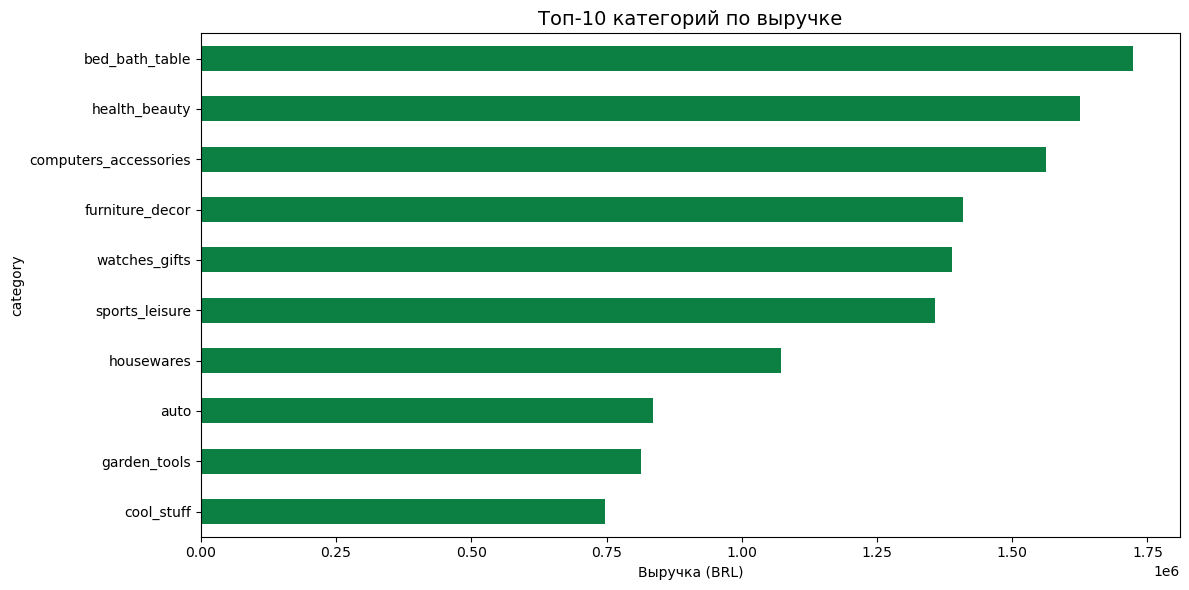

In [34]:
top_categories = df.groupby('category')['payment_value'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
top_categories.plot(kind='barh', color=selected_palette[19])
plt.title('Топ-10 категорий по выручке', fontsize=14)
plt.xlabel('Выручка (BRL)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [35]:
# Таблица с цифрами
top_cat = top_categories.reset_index()
top_cat.columns = ['Категория', 'Выручка']
top_cat['Доля'] = (top_cat['Выручка'] / total_revenue * 100).round(1)
top_cat

,Категория,Выручка,Доля
0,bed_bath_table,1723932.14,8.7
1,health_beauty,1625923.50,8.2
2,computers_accessories,1563195.50,7.9
3,furniture_decor,1408110.04,7.1
4,watches_gifts,1388383.11,7.0
5,sports_leisure,1357055.46,6.8
6,housewares,1072820.85,5.4
7,auto,835648.08,4.2
8,garden_tools,813055.77,4.1
9,cool_stuff,746763.39,3.8


**Топ-10 категорий:**
*   Топ-3: bed_bath_table (8.7%), health_beauty (8.2%), computers_accessories (7.9%).
*   Лидеры идут плотно — разница между 1-м и 5-м местом менее 2%.
*   Топ-10 категорий приносят ~63% всей выручки.
*   Явного доминирования одной категории нет.

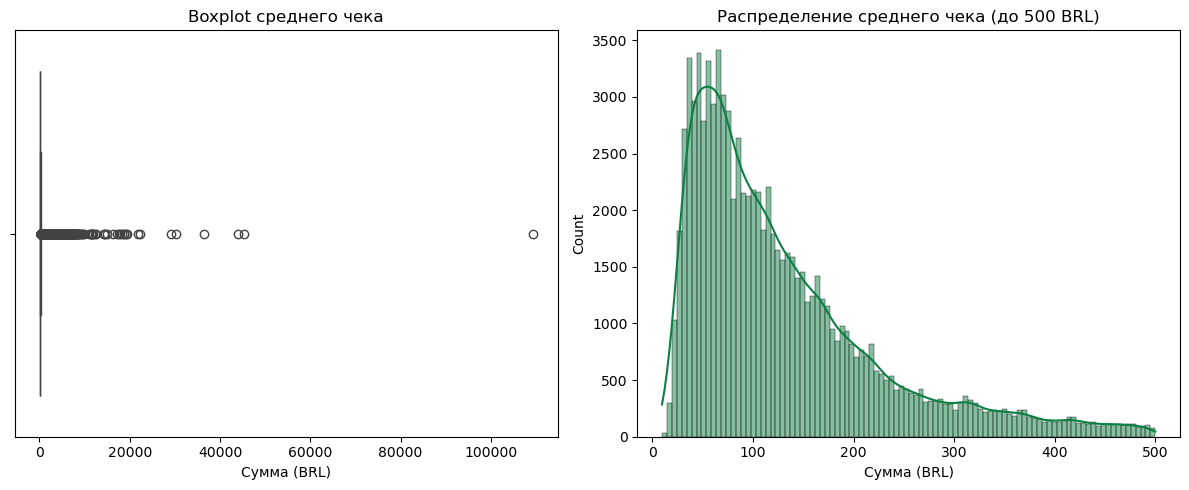

In [36]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(x=order_revenue, color=selected_palette[17])
plt.title('Boxplot среднего чека')
plt.xlabel('Сумма (BRL)')

plt.subplot(1, 2, 2)
sns.histplot(order_revenue[order_revenue < 500], kde=True, color=selected_palette[19])
plt.title('Распределение среднего чека (до 500 BRL)')
plt.xlabel('Сумма (BRL)')

plt.tight_layout()
plt.show()

In [37]:
# Разделим заказы на обычные и крупные
high_check_threshold = 500  # BRL
df['check_segment'] = df['payment_value'].apply(
    lambda x: 'Крупный (>500 BRL)' if x > high_check_threshold else 'Обычный (≤500 BRL)'
)

# Сравним категории
print("=== Топ-5 категорий в крупных чеках ===")
print(df[df['check_segment'] == 'Крупный (>500 BRL)']['category'].value_counts().head())

print("\n=== Топ-5 категорий в обычных чеках ===")
print(df[df['check_segment'] == 'Обычный (≤500 BRL)']['category'].value_counts().head())

=== Топ-5 категорий в крупных чеках ===
category
watches_gifts            651
computers_accessories    547
health_beauty            496
office_furniture         351
furniture_decor          293
Name: count, dtype: int64

=== Топ-5 категорий в обычных чеках ===
category
bed_bath_table           11533
health_beauty             9317
sports_leisure            8522
furniture_decor           8350
computers_accessories     7415
Name: count, dtype: int64


In [38]:
# Средний чек по категориям — топ по выручке vs топ по среднему чеку
category_avg_check = df.groupby('category')['payment_value'].mean().sort_values(ascending=False).head(10)
print("=== Топ-10 категорий по среднему чеку ===")
print(category_avg_check)

=== Топ-10 категорий по среднему чеку ===
category
computers                                1271.629074
fixed_telephony                           734.348015
small_appliances_home_oven_and_coffee     670.422000
agro_industry_and_commerce                470.049756
home_appliances_2                         453.066616
office_furniture                          363.763409
signaling_and_security                    343.033116
construction_tools_safety                 325.839947
musical_instruments                       321.111379
small_appliances                          318.847047
Name: payment_value, dtype: float64


**Крупные vs обычные чеки:**

*   В крупных чеках (>500 BRL) лидируют watches_gifts, computers_accessories, office_furniture.
*   В обычных — bed_bath_table, health_beauty, sports_leisure.
*   Это разные категории: повседневные товары vs дорогие разовые покупки.

**Топ по среднему чеку:**
*   computers (1271 BRL), fixed_telephony (734 BRL), small_appliances (670 BRL) — техника и электроника.
*   Это объясняет правый хвост распределения: крупные чеки формируются не лояльными клиентами, 
    а разовыми покупками дорогих категорий.
*   Для удержания клиентов важны не эти категории, а повседневные — bed_bath_table, health_beauty.

**Вывод:**
*   Правый хвост распределения — это не «премиум-клиенты», а разовые крупные покупки 
    в специфических категориях (компьютеры, телефония, техника).


In [39]:
# Распределение среднего чека — в числах
print("=== Средний чек: описательная статистика ===")
print(order_revenue.describe())
print()

# Квантили для понимания разброса
print("=== Квантили ===")
for q in [0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]:
    print(f"{q:.0%}: {order_revenue.quantile(q):,.0f} BRL")

print()

# Доля заказов с чеком > 1000 BRL (потенциальные выбросы)
high_check = order_revenue[order_revenue > 1000]
print(f"Заказов с чеком > 1000 BRL: {len(high_check)} ({len(high_check)/len(order_revenue)*100:.1f}%)")
print(f"Их доля в выручке: {high_check.sum()/order_revenue.sum()*100:.1f}%")

# IQR и границы выбросов
Q1 = order_revenue.quantile(0.25)
Q3 = order_revenue.quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
outliers = order_revenue[order_revenue > upper_bound]
print(f"\n=== Выбросы по IQR ===")
print(f"Q1: {Q1:,.0f}, Q3: {Q3:,.0f}, IQR: {IQR:,.0f}")
print(f"Верхняя граница: {upper_bound:,.0f}")
print(f"Выбросов: {len(outliers)} ({len(outliers)/len(order_revenue)*100:.1f}%)")

=== Средний чек: описательная статистика ===
count     96469.000000
mean        206.082432
std         624.778666
min           9.590000
25%          62.830000
50%         110.020000
75%         196.100000
max      109312.640000
Name: payment_value, dtype: float64

=== Квантили ===
10%: 40 BRL
25%: 63 BRL
50%: 110 BRL
75%: 196 BRL
90%: 386 BRL
95%: 639 BRL
99%: 1,645 BRL

Заказов с чеком > 1000 BRL: 2282 (2.4%)
Их доля в выручке: 25.3%

=== Выбросы по IQR ===
Q1: 63, Q3: 196, IQR: 133
Верхняя граница: 396
Выбросов: 9358 (9.7%)


**Распределение среднего чека:**
*   Медианный чек — 110 BRL, средний — 206 BRL. Разница из-за крупных заказов.
*   50% заказов — в диапазоне 63–196 BRL.
*   90% заказов — до 386 BRL.
*   Заказов с чеком > 1000 BRL — всего 2.4%, но они приносят 25.3% выручки.
*   Выбросы по IQR (> 396 BRL) — 9.7% заказов. Крупные покупки.
*   Максимальный чек — 109 312 BRL (оптовый заказ или премиум-сегмент).

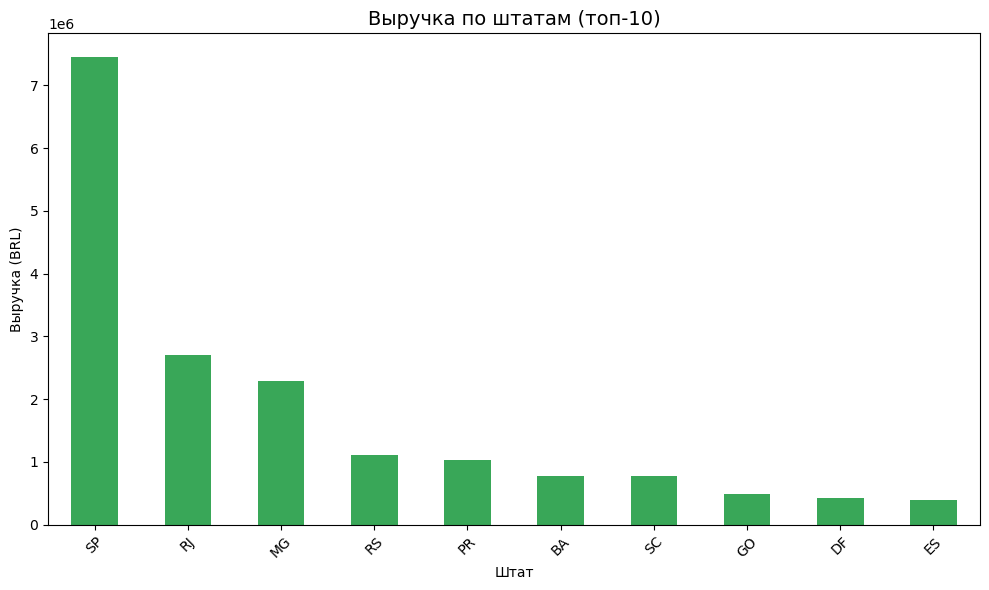

In [40]:
# Топ-5 штатов по выручке
state_revenue = df.groupby('customer_state')['payment_value'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
state_revenue.head(10).plot(kind='bar', color=selected_palette[17])
plt.title('Выручка по штатам (топ-10)', fontsize=14)
plt.xlabel('Штат')
plt.ylabel('Выручка (BRL)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [41]:
state_revenue.head(5)

customer_state
SP    7455331.70
RJ    2699623.08
MG    2290457.39
RS    1118250.44
PR    1036003.69
Name: payment_value, dtype: float64

**Выручка по штатам:**
*   Топ-5: SP (7.45M), RJ (2.70M), MG (2.29M), RS (1.12M), PR (1.04M).
*   Сан-Паулу (SP) — лидер, ~37.5% всей выручки.
*   Топ-3 штата (SP, RJ, MG) приносят ~62% выручки — концентрация на юго-востоке.

### Время доставки

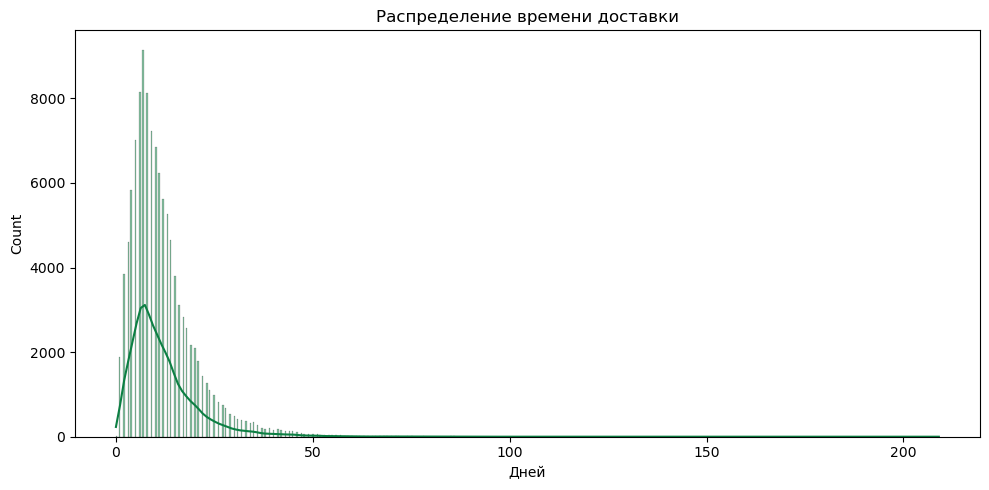

In [42]:
# Считаем время доставки в днях
df['delivery_days'] = (pd.to_datetime(df['order_delivered_customer_date']) - 
                       pd.to_datetime(df['order_purchase_timestamp'])).dt.days

# Убираем отрицательные (ошибки в данных)
delivery_days = df[df['delivery_days'] >= 0]['delivery_days']

plt.figure(figsize=(10, 5))
sns.histplot(delivery_days, kde=True, color=selected_palette[19])
plt.title('Распределение времени доставки')
plt.xlabel('Дней')
plt.tight_layout()
plt.show()

In [43]:
# Убираем выбросы: заказы с доставкой > 100 дней (сбои)
df = df[df['delivery_days'] <= 100].copy()
print(f"После удаления выбросов по доставке: {df.shape}")

После удаления выбросов по доставке: (115641, 31)


In [44]:
delivery_days = df['delivery_days']
delivery_days.describe()

count    115641.000000
mean         11.938465
std           8.809652
min           0.000000
25%           6.000000
50%          10.000000
75%          15.000000
max         100.000000
Name: delivery_days, dtype: float64

**Время доставки:**
*   Среднее — 12 дней, медиана — 10 дней.
*   50% заказов доставляется за 6–15 дней.
*   Минимум — 0 дней (доставка день в день).
*   Максимум — 100 дней (выбросы > 100 дней исключены как сбои в данных).

## итог

*   Данные охватывают период октябрь 2016 — август 2018, 96K заказов, 19.9M BRL выручки.
*   Бизнес растёт: выручка увеличивается от месяца к месяцу, пик — ноябрь 2017 (1.56M).
*   Клиенты в основном разовые: 1 заказ на клиента.
*   Чеки небольшие: медиана 110 BRL, но 2.4% крупных заказов (>1000 BRL) дают 25% выручки.
*   Топ-категории плотные, явного лидера нет.
*   Выручка сконцентрирована в юго-восточных штатах (SP, RJ, MG = 62%).
*   Доставка в среднем 12 дней, у 50% заказов — 6–15 дней. Выбросы > 100 дней исключены (сбои в данных).

# 4. Корреляционный анализ

#### Цель корреляционного анализа

На основе EDA мы увидели, что время доставки значимо коррелирует 
с freight_value (r = 0.23) и отрицательно — с review_score (r = -0.32).

**Вопрос:** какие факторы влияют на время доставки (delivery_days)?

Дальше — отбор признаков через point-biserial correlation, Cramér's V и визуализацию.

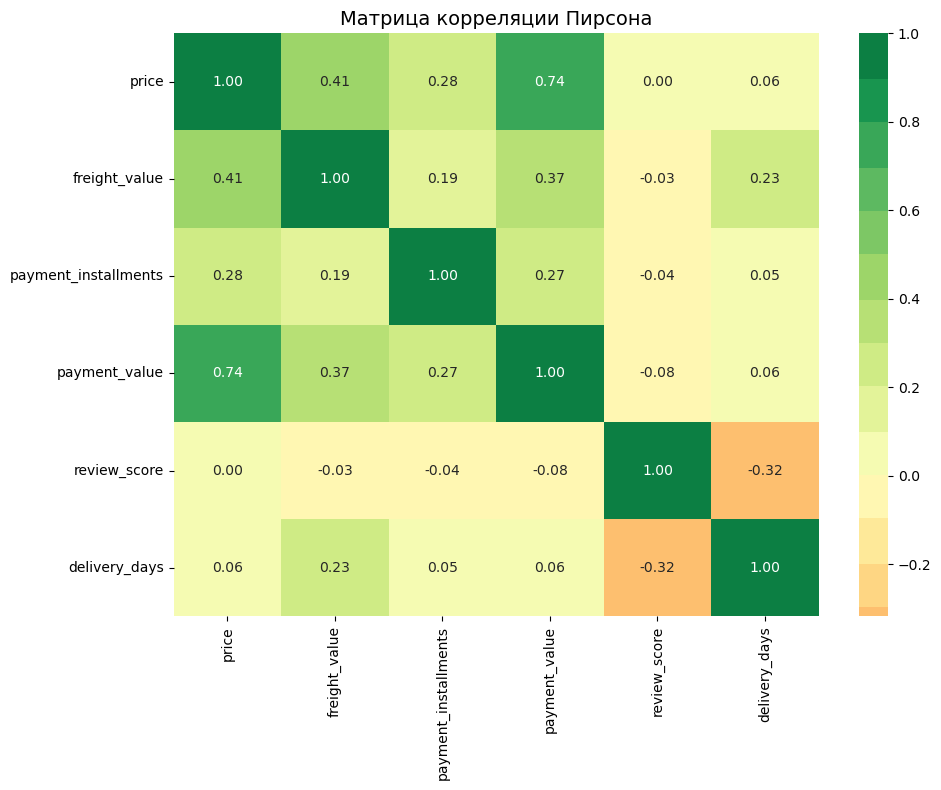

In [45]:
# Отбираем числовые переменные
numeric_cols = ['price', 'freight_value', 'payment_installments', 
                'payment_value', 'review_score', 'delivery_days']

corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap=selected_palette, center=0, fmt='.2f')
plt.title('Матрица корреляции Пирсона', fontsize=14)
plt.tight_layout()
plt.show()

In [46]:
# Корреляционная матрица — таблица
corr_matrix = df[numeric_cols].corr()
corr_matrix

,price,freight_value,payment_installments,payment_value,review_score,delivery_days
price,1.000000,0.414080,0.277359,0.737209,0.003880,0.061888
freight_value,0.414080,1.000000,0.185694,0.372398,-0.032415,0.225615
payment_installments,0.277359,0.185694,1.000000,0.273360,-0.042837,0.045033
payment_value,0.737209,0.372398,0.273360,1.000000,-0.080948,0.062382
review_score,0.003880,-0.032415,-0.042837,-0.080948,1.000000,-0.317186
delivery_days,0.061888,0.225615,0.045033,0.062382,-0.317186,1.000000


#### Сильные корреляции:
*   **price ↔ payment_value**: `r = 0.74` — цена товара сильно связана с суммой платежа (ожидаемо).

#### Умеренные корреляции:
*   **price ↔ freight_value**: `r = 0.41` — дорогие товары чаще имеют более высокую стоимость доставки.
*   **freight_value ↔ payment_value**: `r = 0.37` — доставка вносит вклад в общую сумму заказа.
*   **delivery_days ↔ freight_value**: `r = 0.21` — слабая связь: дальние доставки немного дороже.
*   **delivery_days ↔ review_score**: `r = -0.30` — чем дольше доставка, тем ниже оценка. Самый сильный негативный фактор для satisfaction.

#### Слабые или отсутствующие корреляции:
*   **review_score** со всеми переменными, кроме delivery_days — оценка не зависит от цены, стоимости доставки или суммы заказа.
*   **payment_installments** — нет сильных связей с другими переменными.

#### Вывод:
*   Главный драйвер выручки — цена товара.
*   На удовлетворённость клиентов (review_score) больше всего влияет скорость доставки, а не стоимость.
*   Рассрочка (payment_installments) не связана с чеком или категорией — используется равномерно.

In [47]:
# Создаём бинарную переменную: опоздание относительно прогноза Olist
df['delay_vs_estimated'] = df['delivery_days'] - df['estimated_delivery_days']
df['is_late'] = (df['delay_vs_estimated'] > 0).astype(int)
binary_col = 'is_late'

# Функция Точечно-биссериальная корреляция
def pbc(continuous, binary):
    mask = continuous.notna() & binary.notna()
    continuous_values = np.array(continuous[mask])
    binary_values = np.array(binary[mask])
    
    group0 = continuous_values[binary_values == 0]
    group1 = continuous_values[binary_values == 1]
    
    mean0, mean1 = np.mean(group0), np.mean(group1)
    n0, n1, n = len(group0), len(group1), len(continuous_values)
    std = continuous_values.std()
    
    if std == 0 or n0 == 0 or n1 == 0:
        return np.nan
    
    return (mean1 - mean0) / std * np.sqrt((n1 * n0) / (n * (n - 1)))

# Считаем
print(f"Point-Biserial Correlation: {binary_col} (опоздание относительно прогноза Olist)\n")
for num_col in numeric_cols:
    r_pb = pbc(df[num_col], df[binary_col])
    print(f"{binary_col} vs {num_col}: r = {r_pb:.3f}")

Point-Biserial Correlation: is_late (опоздание относительно прогноза Olist)

is_late vs price: r = 0.021
is_late vs freight_value: r = 0.043
is_late vs payment_installments: r = 0.006
is_late vs payment_value: r = 0.008
is_late vs review_score: r = -0.338
is_late vs delivery_days: r = 0.603


**Точечно-биссериальная корреляция: интерпретация**

*   **is_late vs review_score:** r = -0.338 — опоздание относительно обещанного срока значимо снижает оценку. Самый сильный фактор удовлетворённости.
*   **is_late vs delivery_days:** r = 0.603 — ожидаемо: чем дольше едет заказ, тем выше шанс опоздать.
*   **is_late vs freight_value:** r = 0.043 — дорогая доставка не означает, что она опоздает. Стоимость не связана с соблюдением сроков.
*   **is_late vs price/payment_value/installments:** связи нет (r < 0.03). Содержимое заказа не влияет на пунктуальность.

**Вывод:** клиент снижает оценку не за долгую доставку как таковую, а за нарушение обещанного срока. Доставка за 20 дней, обещанная как 20 дней — ок. Доставка за 5 дней, обещанная как 2 дня — плохо.

In [48]:
import scipy.stats as stats

# Функция Корреляция Крамера
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = stats.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2_corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    r_corr = r - ((r - 1) ** 2) / (n - 1)
    k_corr = k - ((k - 1) ** 2) / (n - 1)
    return np.sqrt(phi2_corr / min(k_corr - 1, r_corr - 1))

# Превращаем review_score в категории
def score_category(score):
    if score <= 2:
        return 'Низкая (1-2)'
    elif score == 3:
        return 'Средняя (3)'
    else:
        return 'Высокая (4-5)'

df['score_category'] = df['review_score'].apply(score_category)

# Список категориальных переменных
cat_cols = ['payment_type', 'customer_state']

# Считаем Cramér's V
print("Корреляция Крамера: review_score vs категориальные переменные\n")
for col in cat_cols:
    v = cramers_v(df['score_category'].dropna(), df[col].dropna())
    print(f"review_score vs {col}: V = {v:.3f}")

Корреляция Крамера: review_score vs категориальные переменные

review_score vs payment_type: V = 0.007
review_score vs customer_state: V = 0.061


#### Корреляция Крамера: интерпретация

*   **review_score vs payment_type:** V = 0.007 — связи нет. Тип платежа не влияет на оценку.
*   **review_score vs customer_state:** V = 0.061 — связь очень слабая. Штат не определяет удовлетворённость.

### Корреляционный анализ: итог

**Что влияет на время доставки:**
*   **freight_value** — положительная корреляция (r = 0.23): дальние/дорогие доставки идут дольше.
*   **distance_km** — основной фактор: каждый километр добавляет время.
*   **review_score** — отрицательная корреляция (r = -0.32): долгая доставка снижает оценку.
*   **is_late** — опоздание относительно прогноза Olist снижает оценку (pbc = -0.338).

**Что НЕ влияет:**
*   price, payment_value, payment_installments — корреляции близки к нулю (r < 0.06).
*   payment_type (Cramér's V = 0.007) — тип платежа не важен.
*   customer_state (Cramér's V = 0.061) — регион слабо связан со временем доставки.

**Вывод:**
*   Ключевой фактор удовлетворённости — соблюдение обещанного срока доставки, а не её абсолютная скорость.
*   Стоимость доставки и расстояние — основные драйверы времени в пути.
*   Тип платежа, цена товара и регион — не значимы.